In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

import os
from pathlib import Path

PROJECT_ROOT = Path(r"A:\Coding\PycharmProjects\cryptoguard")
os.chdir(PROJECT_ROOT)

INPUT_PATH  = PROJECT_ROOT / "data" / "blockchain" / "cleaned.csv"
OUTPUT_DIR  = PROJECT_ROOT / "data" / "blockchain"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#split ratios
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

RANDOM_STATE = 42

Working dir : A:\Coding\PycharmProjects\cryptoguard
Input exists: True
Input path  : A:\Coding\PycharmProjects\cryptoguard\data\blockchain\cleaned.csv
Input  : A:\Coding\PycharmProjects\cryptoguard\data\blockchain\cleaned.csv
Output : A:\Coding\PycharmProjects\cryptoguard\data\blockchain
Splits : train=80%  val=10%  test=10%


In [10]:
df = pd.read_csv(INPUT_PATH)

#schema check
required_cols = {"text", "label", "source"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in input CSV: {missing}")

print(f"Loaded {len(df):,} rows * {len(df.columns)} columns")
print(f"Columns : {list(df.columns)}")
print()

#label check
df['label'] = df['label'].astype(int)
invalid_labels = df[~df['label'].isin([0, 1])]
if len(invalid_labels):
    raise ValueError(f"{len(invalid_labels)} rows with label not in {{0, 1}}")

#null check
null_counts = df[list(required_cols)].isnull().sum()
if null_counts.any():
    print("Null values found:")
    print(null_counts[null_counts > 0])
    df = df.dropna(subset=list(required_cols))
    print(f"Dropped nulls, {len(df):,} rows remain")
else:
    print("No null values")

#balance check
label_dist = df['label'].value_counts().sort_index()
print()
print("Label distribution:")
for lbl, cnt in label_dist.items():
    name = "Legitimate" if lbl == 0 else "Phishing"
    print(f"  {lbl} ({name:10s}): {cnt:,} ({cnt/len(df):.1%})")

imbalance_ratio = label_dist.max() / label_dist.min()
if imbalance_ratio > 1.05:
    print(f"\nImbalance ratio: {imbalance_ratio:.3f}  (>1.05 — check cleaning output)")
else:
    print(f"\nBalanced (ratio: {imbalance_ratio:.3f})")

Loaded 7,952 rows × 3 columns
Columns : ['text', 'label', 'source']

✓  No null values

Label distribution:
  0 (Legitimate): 3,976 (50.0%)
  1 (Phishing  ): 3,976 (50.0%)

✓  Balanced (ratio: 1.000)


In [11]:
print("Source distribution (full dataset):")
src_dist = df['source'].value_counts()
for src, cnt in src_dist.items():
    print(f"  {src:12s}: {cnt:,} ({cnt/len(df):.1%})")

Source distribution (full dataset):
  gemini      : 2,216 (27.9%)
  deepseek    : 1,730 (21.8%)
  chatgpt     : 1,649 (20.7%)
  grok        : 1,446 (18.2%)
  claude      : 911 (11.5%)


In [12]:
df_trainval, df_test = train_test_split(
    df,
    test_size=TEST_RATIO,
    stratify=df['label'],
    random_state=RANDOM_STATE
)

#split train/val from the remaining 90%
#val_ratio within trainval = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
val_ratio_within = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_ratio_within,
    stratify=df_trainval['label'],
    random_state=RANDOM_STATE
)

print("Split sizes:")
print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df):.1%})")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df):.1%})")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/len(df):.1%})")
print(f"  Total : {len(df_train)+len(df_val)+len(df_test):,}")

Split sizes:
  Train : 6,360  (80.0%)
  Val   : 796   (10.0%)
  Test  : 796   (10.0%)
  Total : 7,952


In [13]:
def split_summary(split_df, name):
    dist = split_df['label'].value_counts().sort_index()
    phish = dist.get(1, 0)
    legit = dist.get(0, 0)
    total = len(split_df)
    print(f"{name:6s} | total={total:,}  phishing={phish:,} ({phish/total:.1%})  "
          f"legitimate={legit:,} ({legit/total:.1%})")
    return dist

print("Class balance per split:")
print("\n")
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    split_summary(split, name)

for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    ratio = split['label'].value_counts(normalize=True)
    if abs(ratio[0] - ratio[1]) > 0.02:
        raise RuntimeError(f"Stratification failed for {name} split — check label column")
print("\nAll splits within 2% class balance tolerance")

Class balance per split:
-----------------------------------------------------------------
Train  | total=6,360  phishing=3,180 (50.0%)  legitimate=3,180 (50.0%)
Val    | total=796  phishing=398 (50.0%)  legitimate=398 (50.0%)
Test   | total=796  phishing=398 (50.0%)  legitimate=398 (50.0%)

✓  All splits within 2% class balance tolerance


In [14]:
all_sources = set(df['source'].unique())

print("Source representation per split:")
header = f"{'Source':12s}  {'Full':>6}  {'Train':>6}  {'Val':>6}  {'Test':>6}"
print(header)

missing_in_val  = []
missing_in_test = []

for src in sorted(all_sources):
    n_full  = (df['source']       == src).sum()
    n_train = (df_train['source'] == src).sum()
    n_val   = (df_val['source']   == src).sum()
    n_test  = (df_test['source']  == src).sum()
    print(f"{src:12s}  {n_full:>6,}  {n_train:>6,}  {n_val:>6,}  {n_test:>6,}")
    if n_val  == 0: missing_in_val.append(src)
    if n_test == 0: missing_in_test.append(src)

if missing_in_val:
    print(f"\nSources absent from val  : {missing_in_val}")
if missing_in_test:
    print(f"Sources absent from test : {missing_in_test}")
if not missing_in_val and not missing_in_test:
    print("\nAll sources represented in every split")

Source representation per split:
Source          Full   Train     Val    Test
--------------------------------------------
chatgpt        1,649   1,312     176     161
claude           911     716      96      99
deepseek       1,730   1,382     174     174
gemini         2,216   1,770     212     234
grok           1,446   1,180     138     128

✓  All sources represented in every split


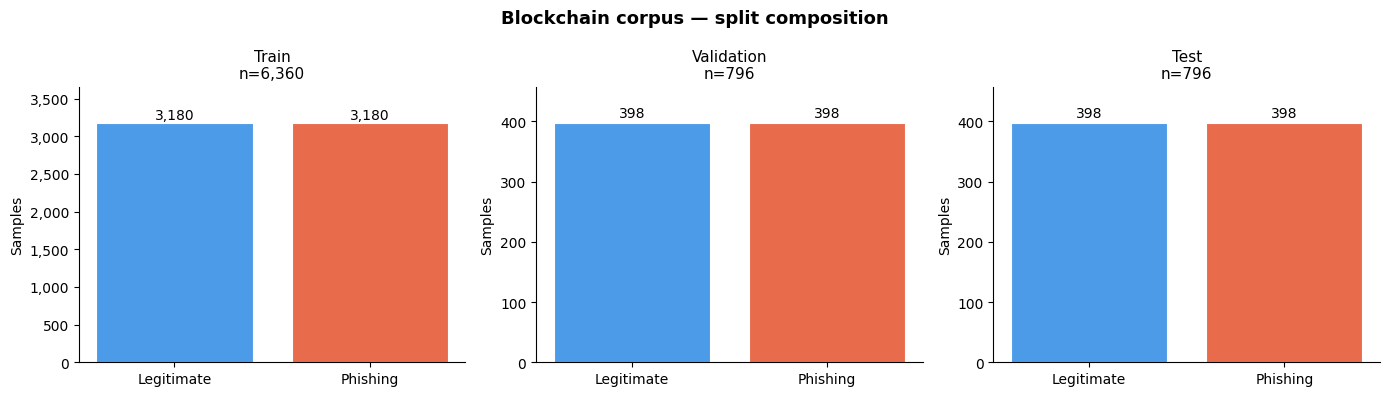

Figure saved → outputs/figures/blockchain_split_distribution.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Blockchain corpus — split composition", fontsize=13, fontweight='bold')

splits_info = [
    (df_train, "Train",      f"n={len(df_train):,}"),
    (df_val,   "Validation", f"n={len(df_val):,}"),
    (df_test,  "Test",       f"n={len(df_test):,}"),
]

colors = ['#4C9BE8', '#E86B4C']

for ax, (split_df, title, subtitle) in zip(axes, splits_info):
    counts = split_df['label'].value_counts().sort_index()
    bars = ax.bar(
        ["Legitimate", "Phishing"],
        [counts.get(0, 0), counts.get(1, 0)],
        color=colors, edgecolor='white', linewidth=0.8
    )
    #annotate bars
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{int(bar.get_height()):,}",
            ha='center', va='bottom', fontsize=10
        )
    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.set_ylabel("Samples")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, max(counts) * 1.15)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figures/blockchain_split_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

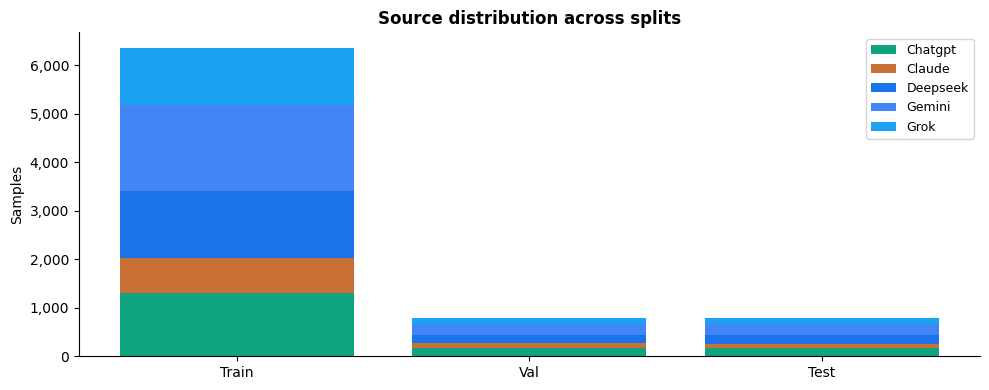

Figure saved → outputs/figures/blockchain_source_per_split.png


In [16]:
#source breakdown per split
fig, ax = plt.subplots(figsize=(10, 4))

source_palette = {
    'gemini':   '#4285F4',
    'deepseek': '#1A73E8',
    'chatgpt':  '#10A37F',
    'grok':     '#1DA1F2',
    'claude':   '#C87036',
}

split_names  = ['Train', 'Val', 'Test']
split_frames = [df_train, df_val, df_test]

source_counts = {
    src: [split['source'].eq(src).sum() for split in split_frames]
    for src in sorted(all_sources)
}

bottoms = [0] * 3
for src, counts in source_counts.items():
    ax.bar(
        split_names, counts,
        bottom=bottoms,
        label=src.capitalize(),
        color=source_palette.get(src, '#999')
    )
    bottoms = [b + c for b, c in zip(bottoms, counts)]

ax.set_title("Source distribution across splits", fontsize=12, fontweight='bold')
ax.set_ylabel("Samples")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figures/blockchain_source_per_split.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    word_counts = split['text'].str.split().str.len()
    print(f"{name:6s} | mean={word_counts.mean():.1f}  "
          f"median={word_counts.median():.0f}  "
          f"min={word_counts.min()}  "
          f"max={word_counts.max()}  "
          f"std={word_counts.std():.1f}")

Train  | mean=32.8  median=31  min=10  max=92  std=14.0
Val    | mean=32.2  median=31  min=10  max=79  std=13.7
Test   | mean=33.4  median=32  min=10  max=75  std=14.0


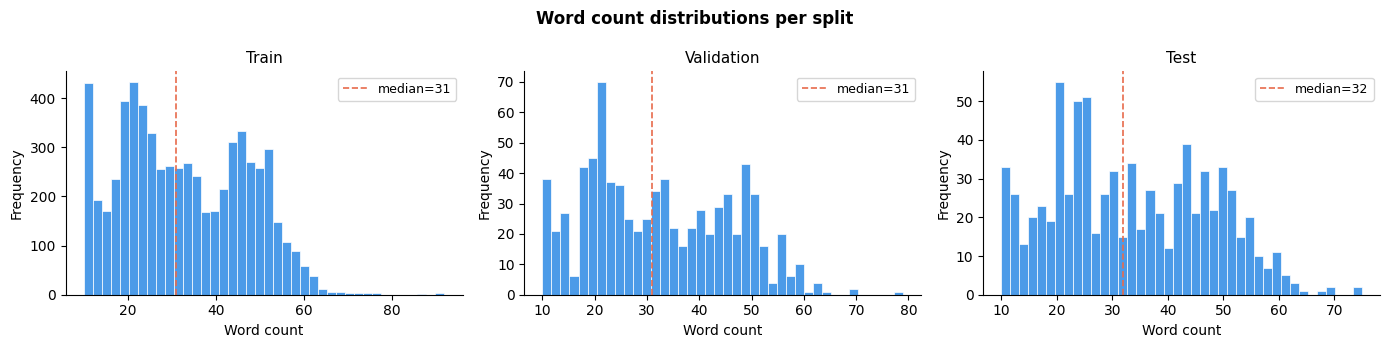

Figure saved → outputs/figures/blockchain_wordcount_dist.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
fig.suptitle("Word count distributions per split", fontsize=12, fontweight='bold')

for ax, (split_df, title, _) in zip(axes, splits_info):
    word_counts = split_df['text'].str.split().str.len()
    ax.hist(word_counts, bins=40, color='#4C9BE8', edgecolor='white', linewidth=0.5)
    ax.axvline(word_counts.median(), color='#E86B4C', linestyle='--', linewidth=1.2,
               label=f"median={word_counts.median():.0f}")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Word count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/figures/blockchain_wordcount_dist.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

train_path = OUTPUT_DIR / "blockchain_train.csv"
val_path   = OUTPUT_DIR / "blockchain_val.csv"
test_path  = OUTPUT_DIR / "blockchain_test.csv"

df_train.to_csv(train_path, index=False)
df_val.to_csv(val_path,     index=False)
df_test.to_csv(test_path,   index=False)

✓  Saved: A:\Coding\PycharmProjects\cryptoguard\data\blockchain\blockchain_train.csv  (6,360 rows)
✓  Saved: A:\Coding\PycharmProjects\cryptoguard\data\blockchain\blockchain_val.csv    (796 rows)
✓  Saved: A:\Coding\PycharmProjects\cryptoguard\data\blockchain\blockchain_test.csv   (796 rows)


In [20]:
def split_metadata(split_df, name):
    label_vc  = split_df['label'].value_counts().sort_index().to_dict()
    source_vc = split_df['source'].value_counts().to_dict()
    wc        = split_df['text'].str.split().str.len()
    return {
        "name":    name,
        "total":   len(split_df),
        "phishing":   int(label_vc.get(1, 0)),
        "legitimate": int(label_vc.get(0, 0)),
        "source_counts": {k: int(v) for k, v in source_vc.items()},
        "word_count_stats": {
            "mean":   round(float(wc.mean()), 2),
            "median": float(wc.median()),
            "std":    round(float(wc.std()), 2),
            "min":    int(wc.min()),
            "max":    int(wc.max()),
        }
    }

meta = {
    "random_state": RANDOM_STATE,
    "input_file":   str(INPUT_PATH),
    "ratios": {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO},
    "splits": [
        split_metadata(df_train, "train"),
        split_metadata(df_val,   "val"),
        split_metadata(df_test,  "test"),
    ]
}

meta_path = OUTPUT_DIR / "blockchain_splits_metadata.json"
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)

print()
print(json.dumps(meta, indent=2))

✓  Metadata saved: A:\Coding\PycharmProjects\cryptoguard\data\blockchain\blockchain_splits_metadata.json

{
  "random_state": 42,
  "input_file": "A:\\Coding\\PycharmProjects\\cryptoguard\\data\\blockchain\\cleaned.csv",
  "ratios": {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1
  },
  "splits": [
    {
      "name": "train",
      "total": 6360,
      "phishing": 3180,
      "legitimate": 3180,
      "source_counts": {
        "gemini": 1770,
        "deepseek": 1382,
        "chatgpt": 1312,
        "grok": 1180,
        "claude": 716
      },
      "word_count_stats": {
        "mean": 32.8,
        "median": 31.0,
        "std": 14.04,
        "min": 10,
        "max": 92
      }
    },
    {
      "name": "val",
      "total": 796,
      "phishing": 398,
      "legitimate": 398,
      "source_counts": {
        "gemini": 212,
        "chatgpt": 176,
        "deepseek": 174,
        "grok": 138,
        "claude": 96
      },
      "word_count_stats": {
        "mean": 32.23,
 

In [21]:
summary = pd.DataFrame([
    {
        "Split":      f"{name} ({int(round(ratio*100))}%)",
        "Phishing":   f"{split['label'].eq(1).sum():,}",
        "Legitimate": f"{split['label'].eq(0).sum():,}",
        "Total":      f"{len(split):,}",
    }
    for name, split, ratio in [
        ("Training",   df_train, TRAIN_RATIO),
        ("Validation", df_val,   VAL_RATIO),
        ("Test",       df_test,  TEST_RATIO),
    ]
])

#add totals row
summary.loc[len(summary)] = [
    "Total",
    f"{df['label'].eq(1).sum():,}",
    f"{df['label'].eq(0).sum():,}",
    f"{len(df):,}",
]

print("Blockchain corpus split summary (for report Table 3.x):")
print(summary.to_string(index=False))

Blockchain corpus split summary (for report Table 3.x):
           Split Phishing Legitimate Total
  Training (80%)    3,180      3,180 6,360
Validation (10%)      398        398   796
      Test (10%)      398        398   796
           Total    3,976      3,976 7,952

READY FOR TRAINING
  blockchain_train.csv → 6,360 samples  (DistilBERT / BERT / RoBERTa)
  blockchain_val.csv   → 796 samples  (early stopping)
  blockchain_test.csv  → 796 samples  (HELD OUT — do not touch until final eval)
